In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv("../../data/placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.shape

(1000, 3)

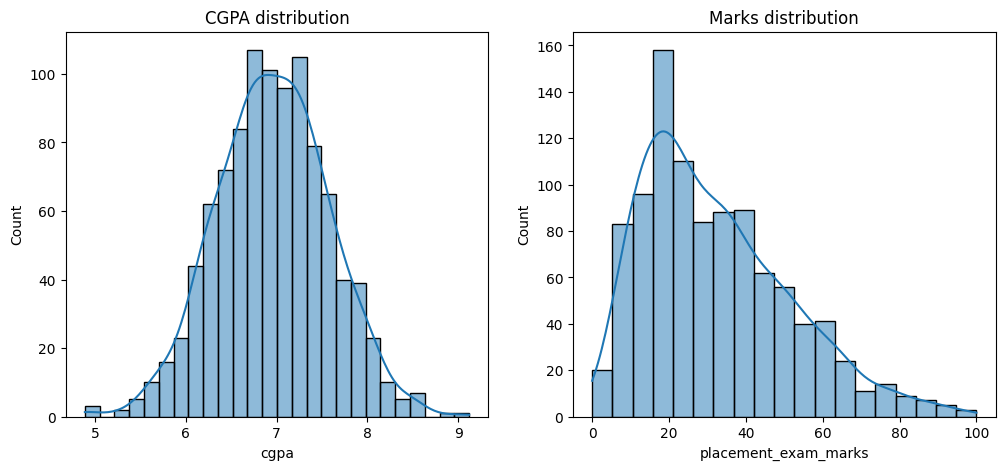

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)
plt.title("CGPA distribution")

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde = True)
plt.title("Marks distribution")

plt.show()

In [6]:
# cgpa - normal distribution, placement marks - skewed

# Therefore, iqr method applied for placement marks outliers

In [8]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

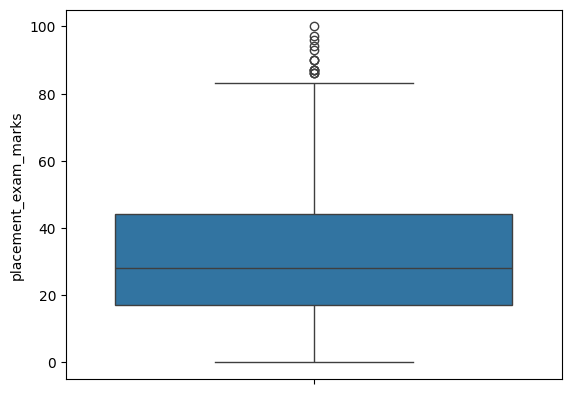

In [9]:
# Plotting the boxplot to check if there are any outliers that need to be taken care of -- 

sns.boxplot(df['placement_exam_marks'])

In [11]:
# finding the 25 percentile, 75 percentile and iqr values

percentile_25 = df['placement_exam_marks'].quantile(0.25)
percentile_75 = df['placement_exam_marks'].quantile(0.75)
iqr = percentile_75 - percentile_25

In [12]:
# storing the boundaries in variables -- 

lower_limit = percentile_25 - 1.5*iqr
upper_limit = percentile_75 + 1.5*iqr

In [14]:
df[(df['placement_exam_marks'] < lower_limit) | (df['placement_exam_marks'] > upper_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [15]:
# 15 outliers are there

In [16]:
# printing the boundaries

lower_limit, upper_limit

(np.float64(-23.5), np.float64(84.5))

In [17]:
# people with marks > 84.5 are outliers

## Trimming --

In [18]:
new_df = df[df['placement_exam_marks'] < upper_limit]
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [19]:
new_df.shape

(985, 3)

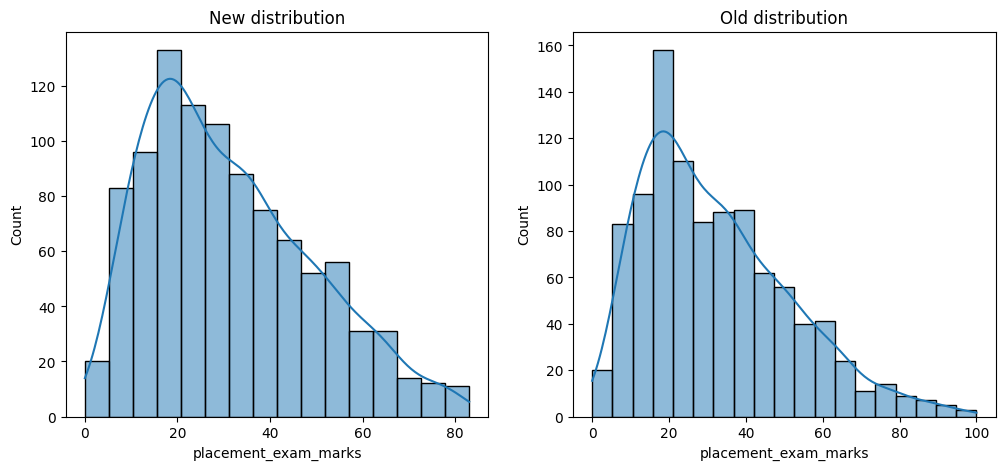

In [21]:
# comparing the distribution of new and old

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.title("New distribution")

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title("Old distribution")

plt.show()

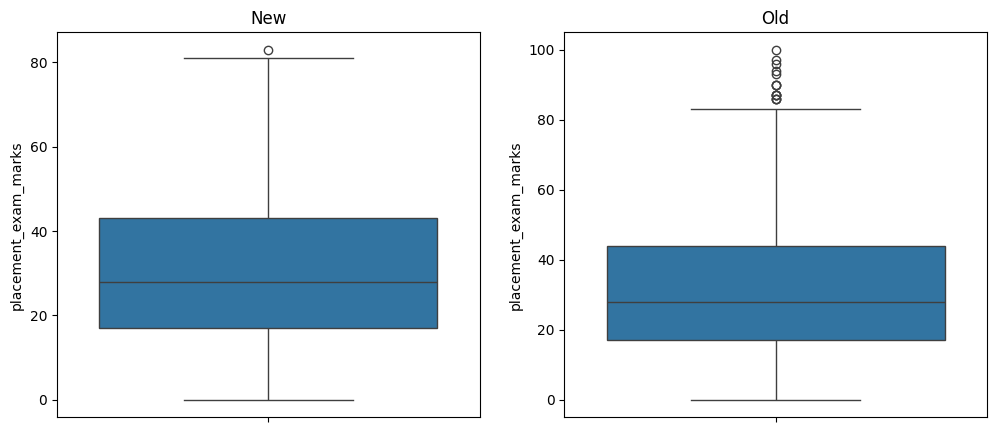

In [22]:
# checking old and new boxplot 

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(new_df['placement_exam_marks'])
plt.title("New")

plt.subplot(1,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.title("Old")

plt.show()

In [23]:
# almost all the outliers have been handled!!

## Capping --

In [24]:
new_df_2 = df.copy()

In [25]:
new_df_2['placement_exam_marks'] = np.where(
    new_df_2['placement_exam_marks'] > upper_limit,
    upper_limit,
    new_df_2['placement_exam_marks']
    )

In [26]:
new_df_2.shape

(1000, 3)

In [27]:
new_df_2.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.136500,0.489000
std,0.615898,18.865419,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,84.500000,1.000000


<Axes: ylabel='placement_exam_marks'>

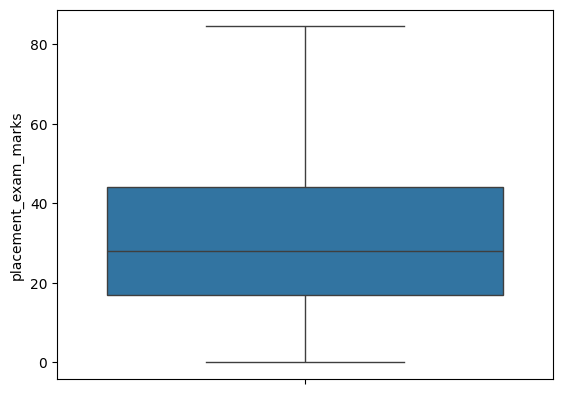

In [28]:
sns.boxplot(new_df_2['placement_exam_marks'])

In [29]:
# done

In [30]:
# :)